In [4]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt

In [2]:
sales = pd.read_csv(
    "../data/processed/sales_daily.csv",
    parse_dates=["Date"]
)

sales.head()

,Date,StockCode,units_sold,revenue,unit_price
0,2009-12-01,10002,12,10.2,0.850
1,2009-12-01,10120,60,12.6,0.210
2,2009-12-01,10123C,3,3.9,1.300
3,2009-12-01,10123G,2,3.4,1.700
4,2009-12-01,10125,5,5.1,1.275


In [3]:
weekly_sales = (
    sales
    .set_index("Date")
    .groupby("StockCode")
    .resample("W")["units_sold"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,StockCode,Date,units_sold
0,10002,2009-12-06,140
1,10002,2009-12-13,24
2,10002,2009-12-20,37
3,10002,2009-12-27,14
4,10002,2010-01-03,0


In [4]:
top_sku = (
    weekly_sales.groupby("StockCode")["units_sold"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

sku_data = weekly_sales[
    weekly_sales["StockCode"] == top_sku
].copy()

sku_data.head()

,StockCode,Date,units_sold
233156,84077,2009-12-06,731
233157,84077,2009-12-13,1204
233158,84077,2009-12-20,720
233159,84077,2009-12-27,48
233160,84077,2010-01-03,0


In [5]:
sku_data["Baseline"] = sku_data["units_sold"].shift(1)

sku_data.dropna(inplace=True)

In [6]:
train_size = int(len(sku_data) * 0.80)

train = sku_data.iloc[:train_size]

test = sku_data.iloc[train_size:]

In [7]:
baseline_mae = mean_absolute_error(
    test["units_sold"],
    test["Baseline"]
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 735.6666666666666


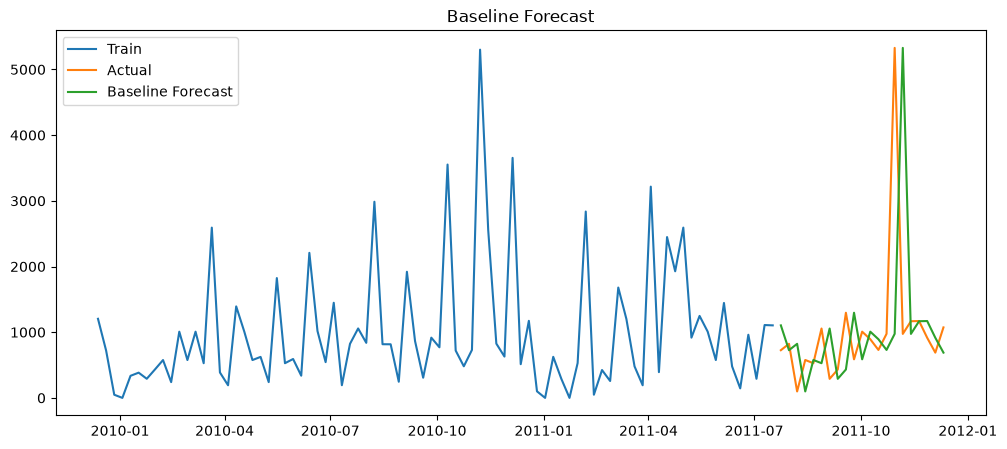

In [8]:
plt.figure(figsize=(12,5))

plt.plot(
    train["Date"],
    train["units_sold"],
    label="Train"
)

plt.plot(
    test["Date"],
    test["units_sold"],
    label="Actual"
)

plt.plot(
    test["Date"],
    test["Baseline"],
    label="Baseline Forecast"
)

plt.legend()

plt.title("Baseline Forecast")

plt.show()

In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [6]:
import pandas as pd

sales = pd.read_csv(
    "../data/processed/sales_daily.csv",
    parse_dates=["Date"]
)

In [7]:
weekly_sales = (
    sales
    .set_index("Date")
    .groupby("StockCode")
    .resample("W")["units_sold"]
    .sum()
    .reset_index()
)

In [8]:
top_sku = (
    weekly_sales
    .groupby("StockCode")["units_sold"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

print(top_sku)

84077


In [9]:
sku_data = weekly_sales[
    weekly_sales["StockCode"] == top_sku
].copy()

sku_data.head()

,StockCode,Date,units_sold
233156,84077,2009-12-06,731
233157,84077,2009-12-13,1204
233158,84077,2009-12-20,720
233159,84077,2009-12-27,48
233160,84077,2010-01-03,0


In [10]:
sku_data["Lag1"] = sku_data["units_sold"].shift(1)
sku_data["Lag2"] = sku_data["units_sold"].shift(2)
sku_data["Lag3"] = sku_data["units_sold"].shift(3)

sku_data["RollingMean"] = (
    sku_data["units_sold"]
    .rolling(3)
    .mean()
)

sku_data.dropna(inplace=True)